In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("sui_factura_promedio_consolidado.csv")

In [3]:
print(df)

                                                Empresa  Anio  Mes  Periodo  \
0                                   AIR-E S.A.S. E.S.P.  2025    1  2025-01   
1                   CARIBEMAR DE LA COSTA S.A.S. E.S.P.  2025    1  2025-01   
2                           CELSIA COLOMBIA S.A. E.S.P.  2025    1  2025-01   
3     CENTRALES ELECTRICAS DEL NORTE DE SANTANDER S....  2025    1  2025-01   
4            CENTRALES ELECTRICAS DE NARIÑO S.A. E.S.P.  2025    1  2025-01   
...                                                 ...   ...  ...      ...   
5804                                 NEU ENERGY SAS ESP  2026    3  2026-03   
5805                                  QI ENERGY SAS ESP  2026    3  2026-03   
5806                         TERPEL ENERGIA S.A.S E.S.P  2026    3  2026-03   
5807  TRANSACCIONES ENERGETICAS S.A.S EMPRESA DE SER...  2026    3  2026-03   
5808                                VATIA S.A.S. E.S.P.  2026    3  2026-03   

                  Segmento  Factura_Promedio_COP  


In [4]:
df.shape

(5809, 6)

El dataset consolidado contiene 5809 registros y 6 variables correspondientes a empresas prestadoras del servicio de energía, segmentos de usuarios y períodos de tiempo.

In [27]:
df.head()

,Empresa,Anio,Mes,Periodo,Segmento,Factura_Promedio_COP
0,AIR-E S.A.S. E.S.P.,2025,1,2025-01,Estrato 1,273094.53
1,CARIBEMAR DE LA COSTA S.A.S. E.S.P.,2025,1,2025-01,Estrato 1,200250.84
2,CELSIA COLOMBIA S.A. E.S.P.,2025,1,2025-01,Estrato 1,87115.06
3,CENTRALES ELECTRICAS DEL NORTE DE SANTANDER S....,2025,1,2025-01,Estrato 1,119172.97
4,CENTRALES ELECTRICAS DE NARIÑO S.A. E.S.P.,2025,1,2025-01,Estrato 1,72510.58


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5809 entries, 0 to 5808
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Empresa               5809 non-null   str    
 1   Anio                  5809 non-null   int64  
 2   Mes                   5809 non-null   int64  
 3   Periodo               5809 non-null   str    
 4   Segmento              5809 non-null   str    
 5   Factura_Promedio_COP  5809 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 272.4 KB


In [7]:
df.describe()

,Anio,Mes,Factura_Promedio_COP
count,5809.000000,5809.000000,5.809000e+03
mean,2025.179205,5.619039,3.206632e+07
std,0.383557,3.586590,1.456852e+08
min,2025.000000,1.000000,-8.444811e+05
25%,2025.000000,2.000000,1.171532e+05
50%,2025.000000,5.000000,4.531160e+05
75%,2025.000000,9.000000,3.406443e+06
max,2026.000000,12.000000,1.969094e+09


Con un promedio mayor que la media, se puede pensar que hay valores muy altos que estan arrastrandoel promedio a que se tenga ese resultado con respecto a la media

In [28]:
df[df["Factura_Promedio_COP"] < 0]

,Empresa,Anio,Mes,Periodo,Segmento,Factura_Promedio_COP
3934,ELECTRIFICADORA DE SANTANDER S.A. E.S.P.,2025,10,2025-10,Otros,-844481.09


Se identifican valores negativos en el promedio de la factura, se debe revisar debido a que puede estar teniendo ese valor negativo  (ajustes contables, devoluciones,subsidios reportados de forma especial, errores de reporte)

In [8]:
df.isnull().sum()

Empresa                 0
Anio                    0
Mes                     0
Periodo                 0
Segmento                0
Factura_Promedio_COP    0
dtype: int64

In [9]:
(df.isnull().sum()/len(df))*100

Empresa                 0.0
Anio                    0.0
Mes                     0.0
Periodo                 0.0
Segmento                0.0
Factura_Promedio_COP    0.0
dtype: float64

Verificamos que no tengamos null debido a los resultados anteriores que puedan estar sesgando el resultado

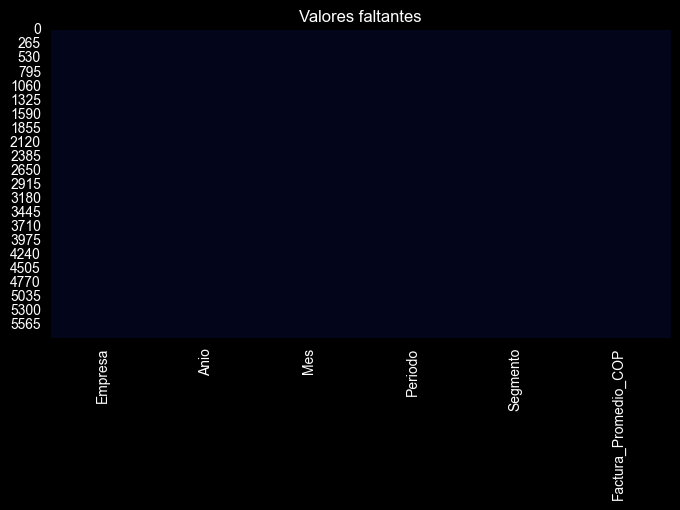

In [10]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Valores faltantes")
plt.show()

No se identificaron valores faltantes después del proceso ETL.

In [11]:
df.duplicated().sum()

np.int64(0)

No se encontraron registros duplicados.

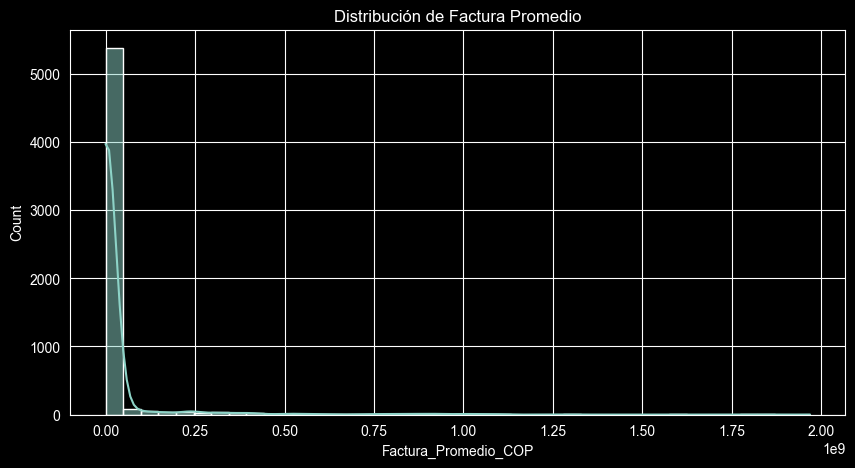

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Factura_Promedio_COP"],
    bins=40,
    kde=True
)

plt.title("Distribución de Factura Promedio")
plt.show()

En el analisis de la campana de Gaus obtenemos : Cola larga a la derecha, lo que nos indica que tenemos una distribucion con asimetria positiva, lo cual puede ser representado por tener un dataset de facturacion

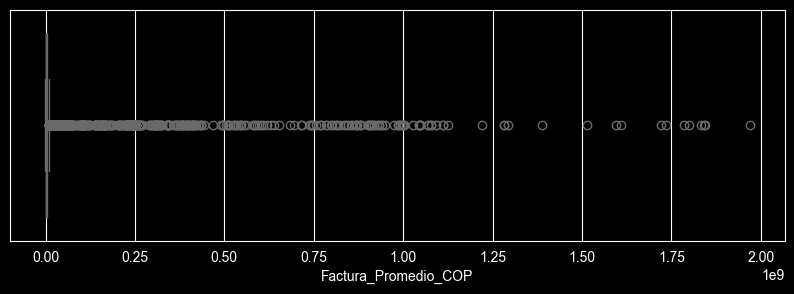

In [29]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["Factura_Promedio_COP"]
)

plt.show()

Vemos que hay empresas con facturas mucho mayores al promedio

In [14]:
df["Empresa"].nunique()

52

In [15]:
df["Empresa"].value_counts().head(15)

Empresa
CELSIA COLOMBIA S.A. E.S.P.                                                       180
CENTRALES ELECTRICAS DEL NORTE DE SANTANDER S.A. ESP                              180
CENTRAL HIDROELECTRICA DE CALDAS S.A. E.S.P. BIC BENEFICIO E INTERES COLECTIVO    180
COMPAÑÍA DE ELECTRICIDAD DE TULUÁ S.A. E.S.P.                                     180
ELECTRIFICADORA DEL META S.A. E.S.P.                                              180
ELECTRIFICADORA DE SANTANDER S.A. E.S.P.                                          180
EMPRESA DE ENERGIA DE BOYACA S.A. E.S.P. EMPRESA DE SERVICIOS PUBLICOS            180
EMPRESAS MUNICIPALES DE CALI   E.I.C.E  E.S.P                                     180
EMPRESAS PÚBLICAS DE MEDELLIN E.S.P.                                              180
ENEL COLOMBIA S.A. E.S.P.                                                         180
VATIA S.A.S. E.S.P.                                                               180
AIR-E S.A.S. E.S.P.                           

Identificamos que no todos los segmentos tienen la misma cantidad de registros

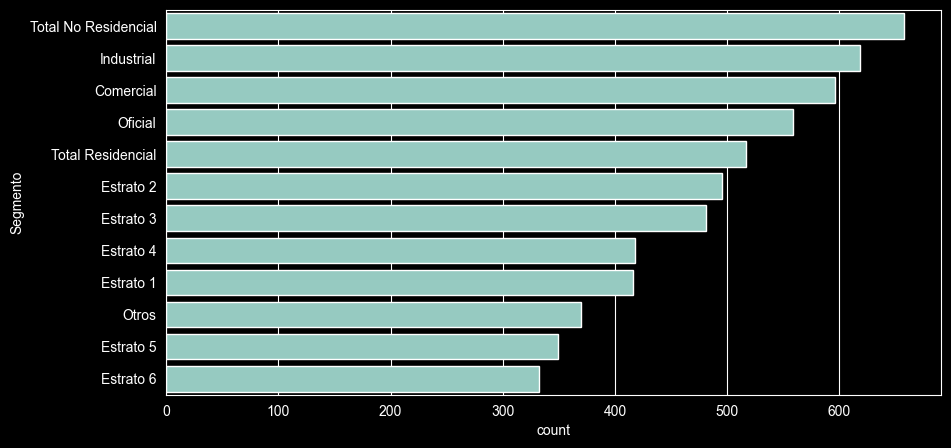

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Segmento",
    order=df["Segmento"].value_counts().index
)

plt.show()

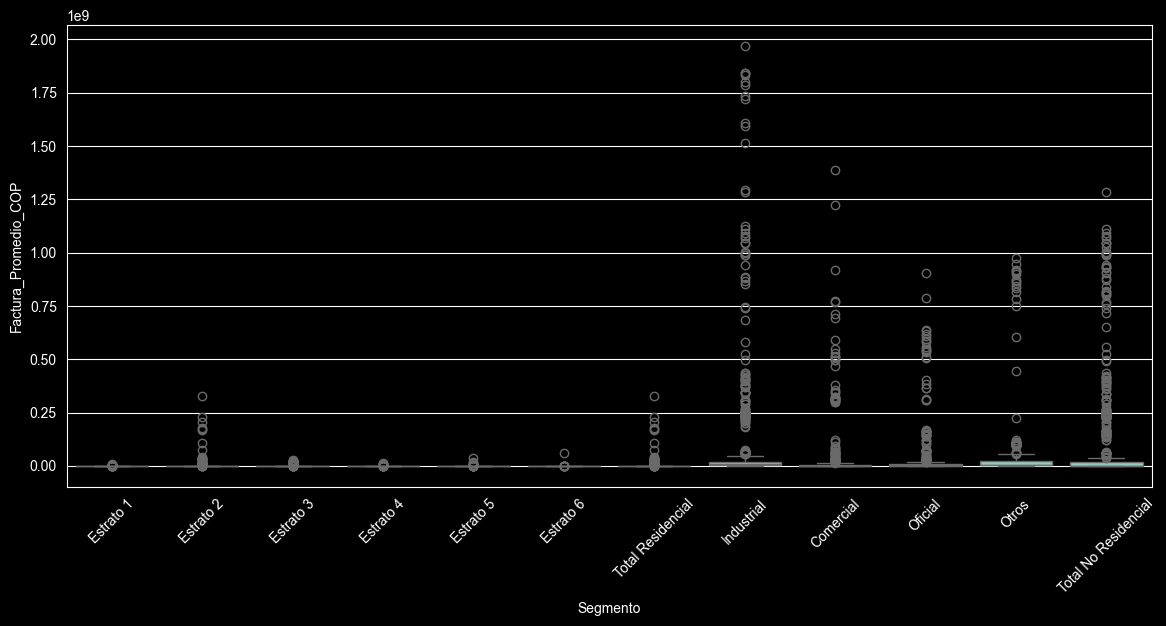

In [17]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="Segmento",
    y="Factura_Promedio_COP"
)

plt.xticks(rotation=45)
plt.show()

El segmento indistruial se evidencia que tiene facturas mas altas al resto de los segmentos